In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [2]:
rfm = pd.read_csv('../data/processed/rfm_features.csv')
rfm_scaled = pd.read_csv('../data/processed/rfm_scaled.csv')

In [3]:
print(rfm.shape, rfm_scaled.shape)

(4338, 4) (4338, 3)


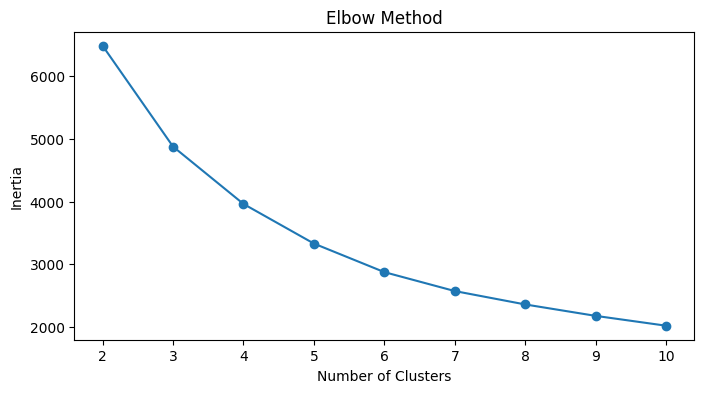

In [5]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)


plt.figure(figsize=(8,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.savefig('../outputs/figures/elbow_method.png', dpi=150)
plt.show()

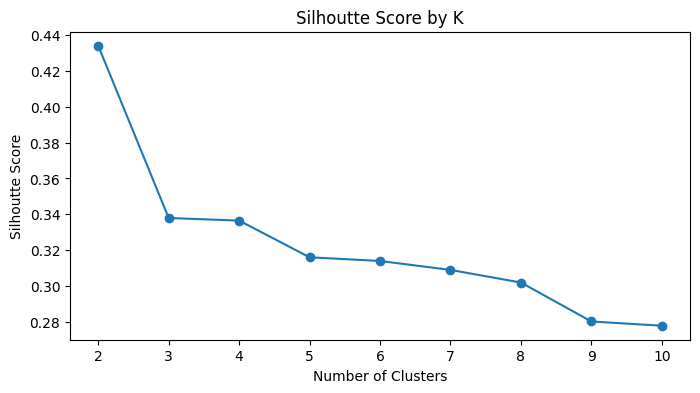

In [7]:
sil_score = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    sil_score.append(score)

plt.figure(figsize=(8,4))
plt.plot(k_range, sil_score, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhoutte Score')
plt.title('Silhoutte Score by K')
plt.savefig('../outputs/figures/silhoutte_score.png', dpi=150)
plt.show()


K=2 scores highest on silhouette but produces only two segments. 
K=3 scores slightly better than k=4 statistically but produces 
only three segments. K=4 is chosen because it maps to four 
distinct and actionable business segments: Champions, Loyal, 
At-Risk, and Lost. The marginal silhouette difference between 
k=3 and k=4 is small enough that business interpretability 
is the deciding factor.

In [9]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

In [10]:
rfm.Cluster.value_counts()

Cluster
0    1622
3    1193
1     810
2     713
Name: count, dtype: int64

In [13]:
cluster_profile = rfm.groupby('Cluster').agg(
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    Count=('Customer ID', 'count')
).round(2)

print(cluster_profile)

         Recency  Frequency  Monetary  Count
Cluster                                     
0         180.77       1.32    341.58   1622
1          17.33       2.14    547.79    810
2          11.45      13.73   8086.12    713
3          70.36       4.09   1800.73   1193


In [14]:
segment_map = {2: 'Champions', 1: 'Promising', 3: 'At-Risk', 0: 'Lost'}

rfm['Segment'] = rfm['Cluster'].map(segment_map)
rfm['Segment'].value_counts()

Segment
Lost         1622
At-Risk      1193
Promising     810
Champions     713
Name: count, dtype: int64

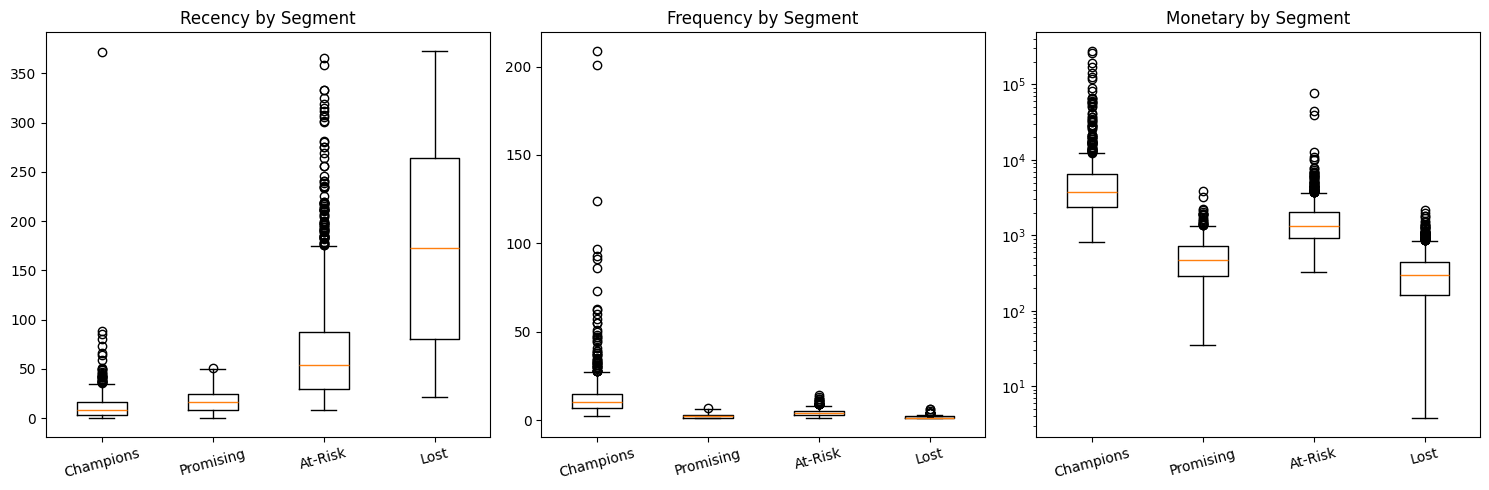

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ["Recency", "Frequency", "Monetary"]

for i, metric in enumerate(metrics):
    data = [rfm[rfm["Segment"] == seg][metric].values for seg in ["Champions", "Promising", "At-Risk", "Lost"]]
    axes[i].boxplot(data, tick_labels=["Champions", "Promising", "At-Risk", "Lost"])
    axes[i].set_title(f"{metric} by Segment")
    axes[i].tick_params(axis="x", rotation=15)

axes[2].set_yscale('log')
plt.tight_layout()
plt.savefig("../outputs/figures/segment_profiles.png", dpi=150)
plt.show()

In [18]:
db = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = db.fit_predict(rfm_scaled)

rfm['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    2762
 1    1485
-1      66
 3      11
 2       7
 4       7
Name: count, dtype: int64

In [19]:
from sklearn.metrics import silhouette_score

mask = rfm["DBSCAN_Cluster"] != -1
db_score = silhouette_score(rfm_scaled[mask], rfm["DBSCAN_Cluster"][mask])
km_score = silhouette_score(rfm_scaled, rfm["Cluster"])

print(f"KMeans Silhouette: {km_score:.4f}")
print(f"DBSCAN Silhouette (excl. noise): {db_score:.4f}")

KMeans Silhouette: 0.3365
DBSCAN Silhouette (excl. noise): 0.1720


In [20]:
comparison = pd.DataFrame({
    "Metric": ["Silhouette Score", "Number of Clusters", "Noise Points", "Business Interpretability"],
    "KMeans": [0.3365, 4, 0, "High"],
    "DBSCAN": [0.1720, 5, 66, "Low"]
})

comparison

,Metric,KMeans,DBSCAN
0,Silhouette Score,0.3365,0.172
1,Number of Clusters,4,5
2,Noise Points,0,66
3,Business Interpretability,High,Low


## Clustering Decision

KMeans with k=4 is selected as the final clustering approach.

DBSCAN produced two dominant clusters and three micro clusters 
of 7-11 customers each, which are not actionable business segments. 
Its silhouette score of 0.17 is significantly lower than KMeans 
at 0.34. DBSCAN is better suited to datasets with irregular 
cluster shapes and meaningful density variation. RFM space 
tends to produce roughly spherical clusters which is exactly 
the geometry KMeans handles well.

KMeans k=4 produces four balanced, interpretable segments 
that map directly to business actions: Champions, Promising, 
At-Risk, and Lost.

In [22]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Segment,DBSCAN_Cluster
0,12346,325,1,77183.60,3,At-Risk,-1
1,12347,2,7,4310.00,2,Champions,0
2,12348,75,4,1797.24,3,At-Risk,0
3,12349,18,1,1757.55,1,Promising,1
4,12350,310,1,334.40,0,Lost,1


In [21]:
rfm_final = rfm[["Customer ID", "Recency", "Frequency", "Monetary", "Segment"]].copy()
rfm_final.to_csv("../data/processed/rfm_labeled.csv", index=False)